# ────────────────────────────────────────────────────────────────
# 03 – Citi Bike JC – Exploratory Data Analysis (EDA)
# ────────────────────────────────────────────────────────────────


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture


# ── Style ─────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

COLORS = {
    'member':   '#2196F3',
    'casual':   '#FF7043',
    'electric': '#4CAF50',
    'classic':  '#9E9E9E',
    'jc':       '#5C6BC0',
    'hoboken':  '#26A69A',
}

DATA_DIR   = "../data"
CLEAN_CSV  = os.path.join(DATA_DIR, "jc_trips_clean.csv")
FIG_DIR    = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIG_DIR, f"{name}.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"  Saved → {path}")

In [2]:
print("Loading clean data...")
df = pd.read_csv(CLEAN_CSV, low_memory=False)

# Datetimes
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at']   = pd.to_datetime(df['ended_at'])

# Categories
for col in ['rideable_type', 'member_casual', 'source_month',
            'start_network', 'end_network']:
    df[col] = df[col].astype('category')

# ── Temporal features ─────────────────────────────────────────────
df['date']       = df['started_at'].dt.date
df['hour']       = df['started_at'].dt.hour
df['day_of_week']= df['started_at'].dt.dayofweek          # 0=Mon
df['day_name']   = df['started_at'].dt.day_name()
df['month']      = df['started_at'].dt.to_period('M').astype(str)
df['is_weekend'] = df['day_of_week'] >= 5
df['is_rush']    = df['hour'].isin(range(7, 10)) | df['hour'].isin(range(17, 20))

def season(dt):
    m = dt.month
    if m in (12, 1, 2):  return 'Winter'
    if m in (3, 4, 5):   return 'Spring'
    if m in (6, 7, 8):   return 'Summer'
    return 'Fall'

df['season'] = df['started_at'].apply(season).astype('category')

# ── Haversine distance ────────────────────────────────────────────
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # metres
    φ1, φ2 = radians(lat1), radians(lat2)
    dφ = radians(lat2 - lat1)
    dλ = radians(lon2 - lon1)
    a = sin(dφ/2)**2 + cos(φ1)*cos(φ2)*sin(dλ/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

coord_mask = (
    df['start_lat'].notna() & df['start_lng'].notna() &
    df['end_lat'].notna()   & df['end_lng'].notna()
)
df.loc[coord_mask, 'distance_m'] = df[coord_mask].apply(
    lambda r: haversine(r.start_lat, r.start_lng, r.end_lat, r.end_lng), axis=1
)
df['distance_km'] = df['distance_m'] / 1000

# Speed (km/h) — only for trips with valid distance and duration > 1 min
speed_mask = coord_mask & (df['duration_min'] > 1) & (df['distance_km'] > 0.05)
df.loc[speed_mask, 'speed_kmh'] = (
    df.loc[speed_mask, 'distance_km'] / (df.loc[speed_mask, 'duration_min'] / 60)
)

print(f"Shape: {df.shape}")
print(f"Trips with distance: {coord_mask.sum():,} ({coord_mask.mean()*100:.1f}%)")

Loading clean data...
Shape: (1093685, 29)
Trips with distance: 1,092,351 (99.9%)


In [3]:
print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"  Total trips:      {len(df):>10,}")
print(f"  Date range:       {df['started_at'].min().date()} → {df['started_at'].max().date()}")
print(f"  Unique stations:  {df['start_station_name'].nunique():>10,}  (start)")
print(f"                    {df['end_station_name'].nunique():>10,}  (end)")

print("\n  Member / Casual:")
print(df['member_casual'].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n  Rideable type:")
print(df['rideable_type'].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n  Network (start):")
print(df['start_network'].value_counts().to_string())

print("\n  Season distribution:")
print(df['season'].value_counts().to_string())

  DATASET OVERVIEW
  Total trips:       1,093,685
  Date range:       2024-11-30 → 2026-01-31
  Unique stations:         112  (start)
                           499  (end)

  Member / Casual:
member_casual
member    78.4
casual    21.6

  Rideable type:
rideable_type
electric_bike    64.6
classic_bike     35.4

  Network (start):
start_network
jersey_city    596328
hoboken        497357

  Season distribution:
season
Summer    312342
Fall      295923
Spring    247410
Winter    238010


In [6]:
# End stations that never appear as a start station
start_stations = set(df['start_station_name'].dropna().unique())
end_only = df[~df['end_station_name'].isin(start_stations)]['end_station_name'].dropna()

print(f"End-only station names: {end_only.nunique():,}")
print("\nSample:")
print(end_only.value_counts().head(20).to_string())

End-only station names: 387

Sample:
end_station_name
Vesey Pl & River Terrace         509
North Moore St & Greenwich St    237
Pier 61 at Chelsea Piers         103
Vesey St & Church St              92
12 Ave & W 40 St                  92
River Ter & Warren St             86
9 Ave & W 33 St                   82
E 40 St & 5 Ave                   81
West St & Chambers St             75
10 Ave & W 14 St                  64
W 30 St & 10 Ave                  61
N 12 St & Bedford Ave             58
Greenwich St & Hubert St          56
W 34 St & Hudson Blvd E           55
W 34 St & 11 Ave                  55
Church St & Worth St              53
Grand St & Greene St              50
W 44 St & 5 Ave                   45
Bleecker St & Crosby St           44
Vesey St & Greenwich St           42


## End Station Discrepancy — 499 end stations vs 112 start stations

Of the 499 unique end station names, 387 never appear as a start station.
These are not JC or Hoboken stations — they are NYC Citi Bike stations 
(Manhattan and Brooklyn), identifiable by their street-intersection naming 
convention (e.g. `Vesey Pl & River Terrace`, `9 Ave & W 33 St`).

This means a meaningful slice of trips in the dataset are one-way 
cross-Hudson rides that start in Jersey City or Hoboken and end in Manhattan. 
These riders do not return the bike to a JC/HB station — they dock in NYC and presumably commute back by PATH train or ferry.

These trips are captured in the `end_network == 'other'` flag added during 
cleaning (3,571 trips, ~0.3% of the dataset).

Implications for analysis:
- Station-level analysis should filter on `start_network` or use 
  `start_station_name` — the 112 start stations are the true JC+Hoboken network
- Distance and duration for cross-Hudson trips will be longer than average 
  and should be treated as a distinct trip type
- `trip_type == 'JC → other'` or `'HB → other'` can be used to isolate 
  and analyse this commuter pattern separately

In [7]:
# Flag cross-Hudson trips for use throughout EDA
df['is_cross_hudson'] = df['end_network'].astype(str) == 'other'
print(f"Cross-Hudson trips: {df['is_cross_hudson'].sum():,} ({df['is_cross_hudson'].mean()*100:.2f}%)")

Cross-Hudson trips: 3,571 (0.33%)


## Section 1 - Temporal patterns

  Saved → ../figures\01_monthly_ridership.png


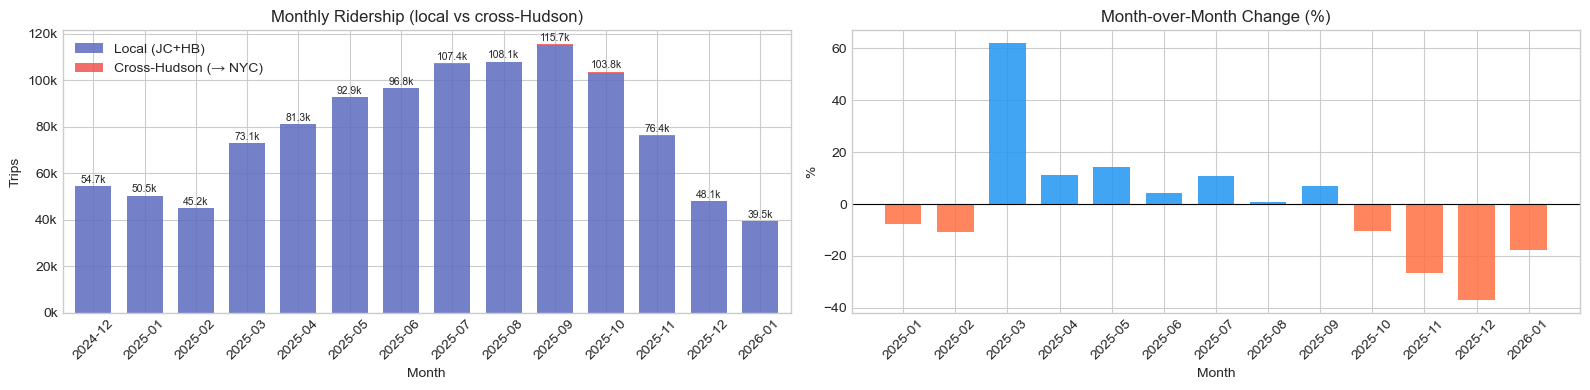

In [8]:
# Exclude partial month Nov 2024
monthly = (df[df['month'] >= '2024-12']
           .groupby(['month', 'is_cross_hudson'])
           .size()
           .unstack(fill_value=0)
           .rename(columns={False: 'local', True: 'cross_hudson'}))

monthly['total'] = monthly.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left — total with cross-Hudson stacked
monthly[['local', 'cross_hudson']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[COLORS['jc'], '#EF5350'],
    alpha=0.85, width=0.7
)
axes[0].set_title('Monthly Ridership (local vs cross-Hudson)', fontsize=12)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Trips')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['Local (JC+HB)', 'Cross-Hudson (→ NYC)'])

# Annotate totals
for i, (idx, row) in enumerate(monthly.iterrows()):
    axes[0].text(i, row['total'] + 500, f"{row['total']/1000:.1f}k",
                 ha='center', va='bottom', fontsize=7.5)

# Right — month-over-month % change
mom = monthly['total'].pct_change().mul(100).dropna()
colors_mom = [COLORS['member'] if v >= 0 else COLORS['casual'] for v in mom]
axes[1].bar(mom.index, mom.values, color=colors_mom, alpha=0.85, width=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Month-over-Month Change (%)', fontsize=12)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
savefig('01_monthly_ridership')
plt.show()

  Saved → ../figures\02_monthly_member_casual.png


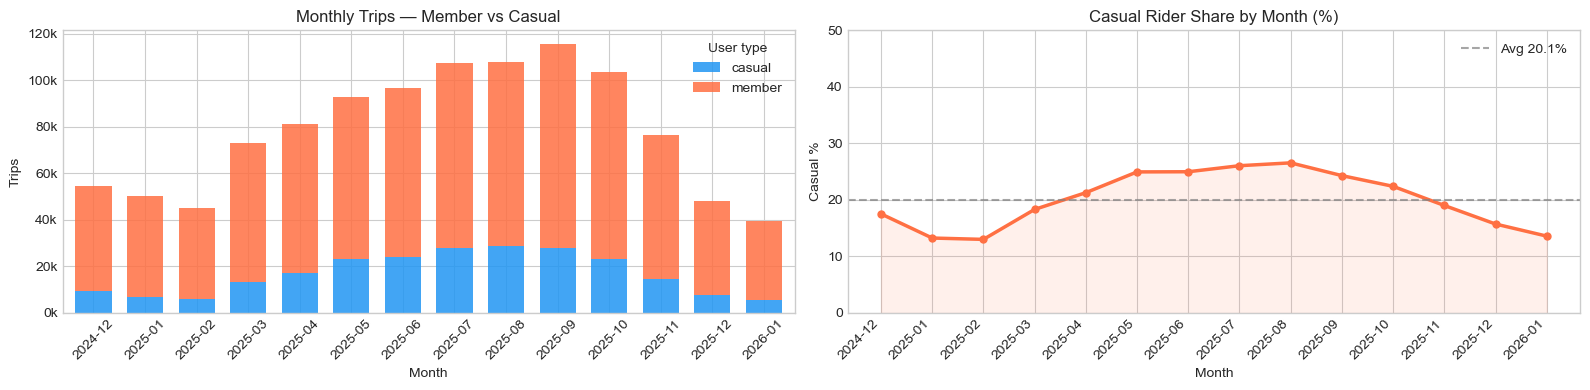

In [9]:
monthly_split = (df[df['month'] >= '2024-12']
                 .groupby(['month', 'member_casual'])
                 .size()
                 .unstack(fill_value=0)
                 .sort_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Stacked bar
monthly_split.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[COLORS['member'], COLORS['casual']],
    alpha=0.85, width=0.7
)
axes[0].set_title('Monthly Trips — Member vs Casual', fontsize=12)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Trips')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='User type')

# Casual share % line
casual_pct = (monthly_split['casual'] / monthly_split.sum(axis=1) * 100)
axes[1].plot(casual_pct.index, casual_pct.values,
             color=COLORS['casual'], linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(range(len(casual_pct)), casual_pct.values,
                     alpha=0.1, color=COLORS['casual'])
axes[1].set_title('Casual Rider Share by Month (%)', fontsize=12)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Casual %')
axes[1].set_ylim(0, 50)
axes[1].axhline(casual_pct.mean(), linestyle='--', color='gray',
                alpha=0.7, label=f'Avg {casual_pct.mean():.1f}%')
axes[1].set_xticks(range(len(casual_pct)))
axes[1].set_xticklabels(casual_pct.index, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
savefig('02_monthly_member_casual')
plt.show()

  Saved → ../figures\03_heatmap_dow_hour.png


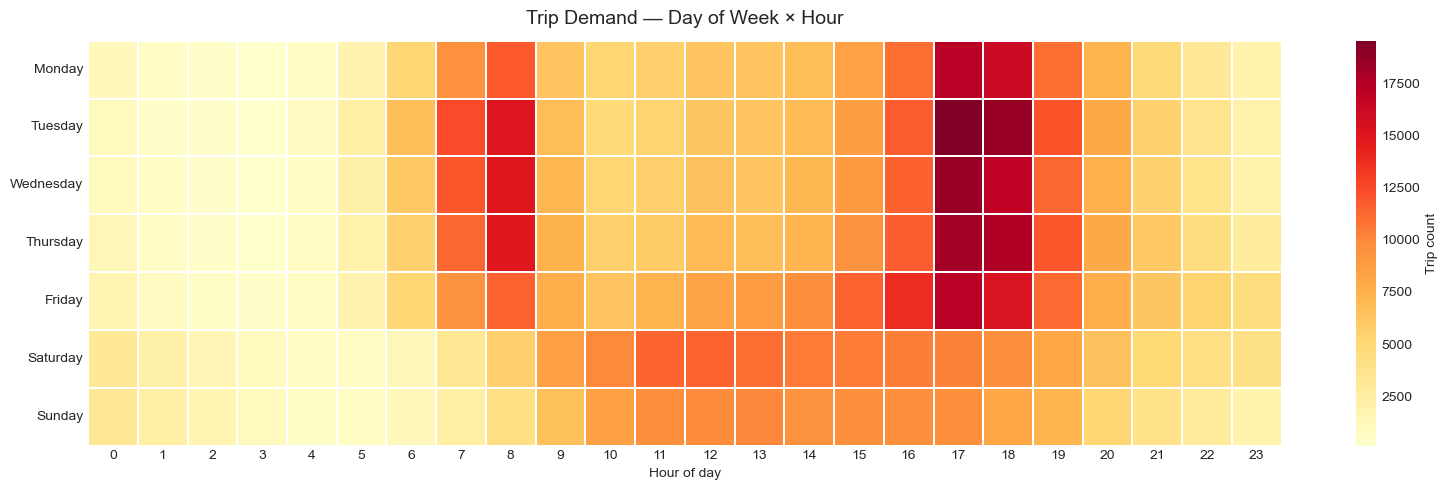

In [10]:
DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

heatmap_data = (df.groupby(['day_name', 'hour'])
                  .size()
                  .unstack(fill_value=0)
                  .reindex(DAY_ORDER))

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Trip count'},
    fmt='d'
)
ax.set_title('Trip Demand — Day of Week × Hour', fontsize=14, pad=12)
ax.set_xlabel('Hour of day')
ax.set_ylabel('')

plt.tight_layout()
savefig('03_heatmap_dow_hour')
plt.show()

C:\Users\aghab\AppData\Local\Temp\ipykernel_27908\310958323.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly = (df.groupby(['hour', 'member_casual', 'is_weekend'])


  Saved → ../figures\04_hourly_weekday_weekend.png


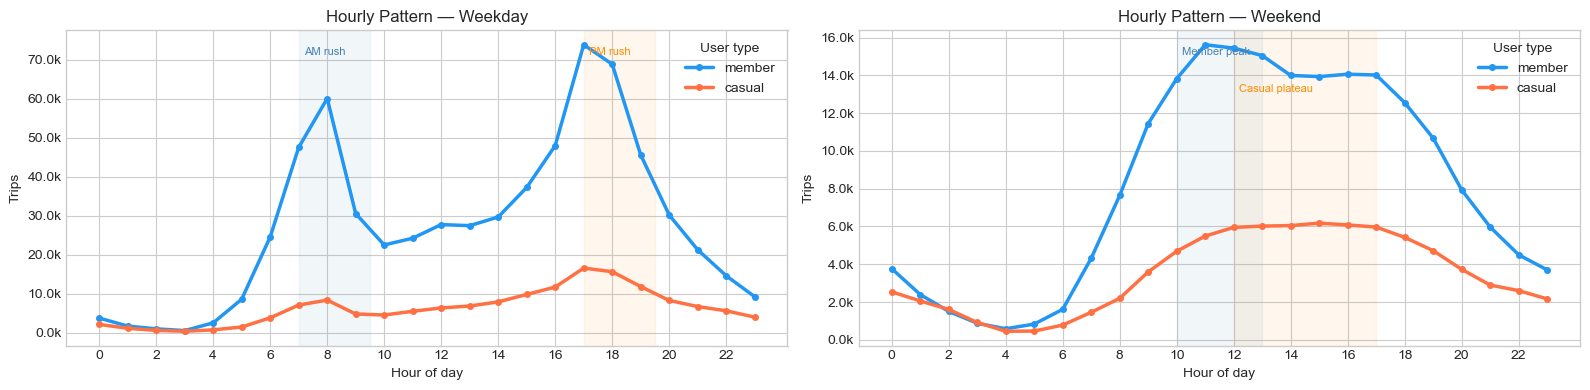

In [5]:
hourly = (df.groupby(['hour', 'member_casual', 'is_weekend'])
            .size()
            .reset_index(name='trips'))

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)

for ax, is_wknd, title in zip(axes, [False, True], ['Weekday', 'Weekend']):
    sub = hourly[hourly['is_weekend'] == is_wknd]
    for user, color in [('member', COLORS['member']), ('casual', COLORS['casual'])]:
        data = sub[sub['member_casual'] == user]
        ax.plot(data['hour'], data['trips'],
                color=color, linewidth=2.5, marker='o', markersize=4, label=user)

    ylim_top = ax.get_ylim()[1]

    if not is_wknd:
        # Weekday — commuter rush bands
        ax.axvspan(7,  9.5,  alpha=0.07, color='steelblue')
        ax.axvspan(17, 19.5, alpha=0.07, color='darkorange')
        ax.text(7.2,  ylim_top * 0.92, 'AM rush', fontsize=8, color='steelblue')
        ax.text(17.2, ylim_top * 0.92, 'PM rush', fontsize=8, color='darkorange')
    else:
        # Weekend — leisure peaks, no commuter pattern
        ax.axvspan(10, 13, alpha=0.07, color='steelblue')
        ax.axvspan(12, 17, alpha=0.07, color='darkorange')
        ax.text(10.2, ylim_top * 0.92, 'Member peak',  fontsize=8, color='steelblue')
        ax.text(12.2, ylim_top * 0.80, 'Casual plateau', fontsize=8, color='darkorange')

    ax.set_title(f'Hourly Pattern — {title}', fontsize=12)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Trips')
    ax.set_xticks(range(0, 24, 2))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}k'))
    ax.legend(title='User type')

plt.tight_layout()
savefig('04_hourly_weekday_weekend')
plt.show()

## Section 2 - Duration and Distance

  Saved → ../figures\05_duration_distribution.png


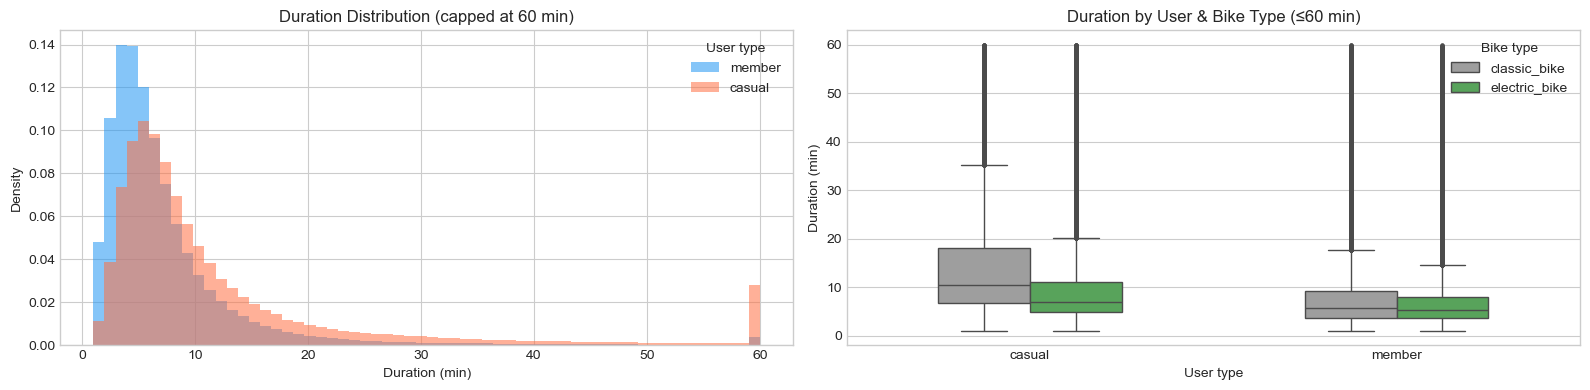


Duration stats (min):
                  count   mean    std  min   25%   50%    75%    95%      max
member_casual                                                                
casual         235837.0  13.91  32.98  1.0  5.27  7.91  13.34  41.37  1432.56
member         857848.0   8.09  24.97  1.0  3.68  5.53   8.52  18.72  1439.31


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Histogram overlay capped at 60 min
for user, color in [('member', COLORS['member']), ('casual', COLORS['casual'])]:
    sub = df.loc[df['member_casual'] == user, 'duration_min'].clip(upper=60)
    axes[0].hist(sub, bins=60, alpha=0.55, color=color, label=user, density=True)

axes[0].set_title('Duration Distribution (capped at 60 min)', fontsize=12)
axes[0].set_xlabel('Duration (min)')
axes[0].set_ylabel('Density')
axes[0].legend(title='User type')

# Box plot: user type × bike type
bp_data = df[df['duration_min'] <= 60]
sns.boxplot(
    data=bp_data,
    x='member_casual', y='duration_min',
    hue='rideable_type',
    palette={'electric_bike': COLORS['electric'], 'classic_bike': COLORS['classic']},
    ax=axes[1], width=0.5,
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3}
)
axes[1].set_title('Duration by User & Bike Type (≤60 min)', fontsize=12)
axes[1].set_xlabel('User type')
axes[1].set_ylabel('Duration (min)')
axes[1].legend(title='Bike type')

plt.tight_layout()
savefig('05_duration_distribution')
plt.show()

print("\nDuration stats (min):")
print(df.groupby('member_casual')['duration_min']
        .describe(percentiles=[.25, .5, .75, .95])
        .round(2).to_string())

  Saved → ../figures\06_distance_distribution.png


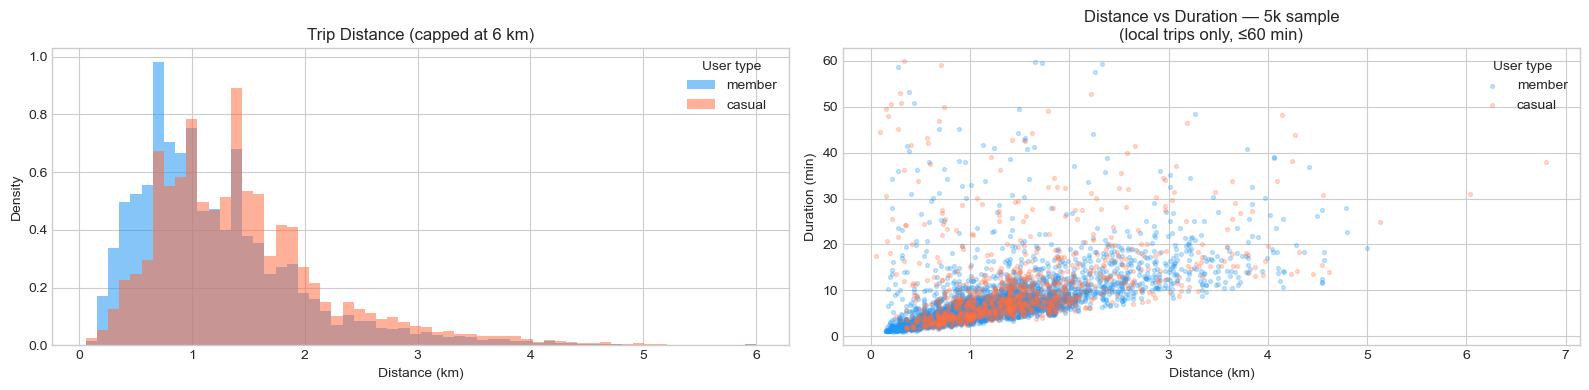


Distance stats (km):
                  count   mean    std    min    50%    75%    95%     max
member_casual                                                            
casual         217784.0  1.453  0.795  0.057  1.345  1.800  3.019  18.348
member         836267.0  1.209  0.749  0.057  1.030  1.531  2.695  15.377


In [13]:
dist_df = df[df['distance_km'].notna() & (df['distance_km'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Histogram by user type, capped at 6 km
for user, color in [('member', COLORS['member']), ('casual', COLORS['casual'])]:
    sub = dist_df.loc[dist_df['member_casual'] == user, 'distance_km'].clip(upper=6)
    axes[0].hist(sub, bins=60, alpha=0.55, color=color, label=user, density=True)

axes[0].set_title('Trip Distance (capped at 6 km)', fontsize=12)
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Density')
axes[0].legend(title='User type')

# Scatter: distance vs duration (5k sample, exclude cross-Hudson outliers)
sample = (dist_df[~dist_df['is_cross_hudson'] & (dist_df['duration_min'] <= 60)]
          .sample(5000, random_state=42))
for user, color in [('member', COLORS['member']), ('casual', COLORS['casual'])]:
    sub = sample[sample['member_casual'] == user]
    axes[1].scatter(sub['distance_km'], sub['duration_min'],
                    alpha=0.25, s=8, color=color, label=user)

axes[1].set_title('Distance vs Duration — 5k sample\n(local trips only, ≤60 min)', fontsize=12)
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Duration (min)')
axes[1].legend(title='User type')

plt.tight_layout()
savefig('06_distance_distribution')
plt.show()

print("\nDistance stats (km):")
print(dist_df.groupby('member_casual')['distance_km']
             .describe(percentiles=[.5, .75, .95])
             .round(3).to_string())

  Saved → ../figures\bimodal_01_kde_peaks.png


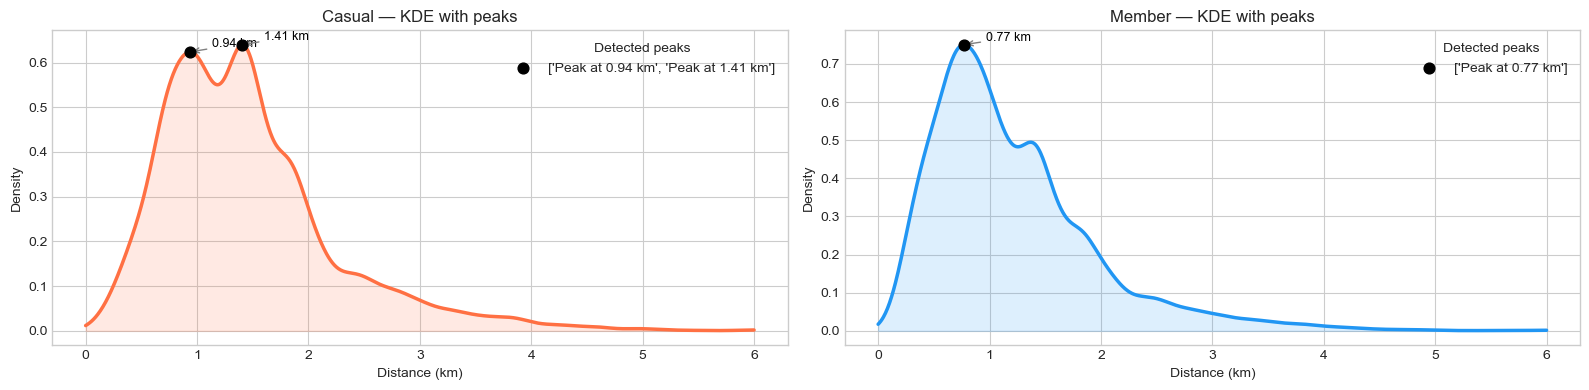


Casual — BIC scores: {1: np.float64(514749.6956223048), 2: np.float64(457302.4861214337), 3: np.float64(452620.4185010743)}
  Best fit: 3 component(s)
  Component 1: mean=1.57 km, std=0.35, weight=42.00%
  Component 2: mean=2.77 km, std=0.85, weight=15.28%
  Component 3: mean=0.86 km, std=0.30, weight=42.73%

Member — BIC scores: {1: np.float64(1881185.127615828), 2: np.float64(1635219.1165746932), 3: np.float64(1578608.0491575904)}
  Best fit: 3 component(s)
  Component 1: mean=1.50 km, std=0.36, weight=35.06%
  Component 2: mean=2.71 km, std=0.82, weight=10.63%
  Component 3: mean=0.73 km, std=0.27, weight=54.31%
  Saved → ../figures\bimodal_02_gmm_components.png


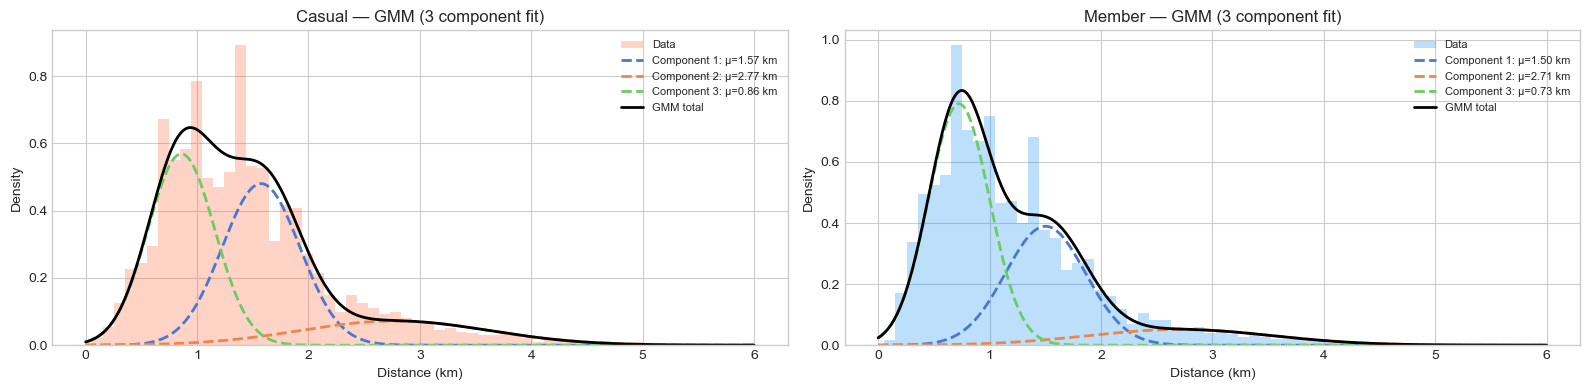


Casual rider GMM split:
trip_profile
short    187408
long      30376
Name: count, dtype: int64

Profile comparison:
                   n  median_dist  median_dur  pct_electric  pct_weekend  \
trip_profile                                                               
long           30376         2.77       15.52         76.72         0.39   
short         187408         1.21        6.84         74.43         0.34   

              pct_rush  
trip_profile            
long              0.35  
short             0.38  
  Saved → ../figures\bimodal_03_casual_profiles.png


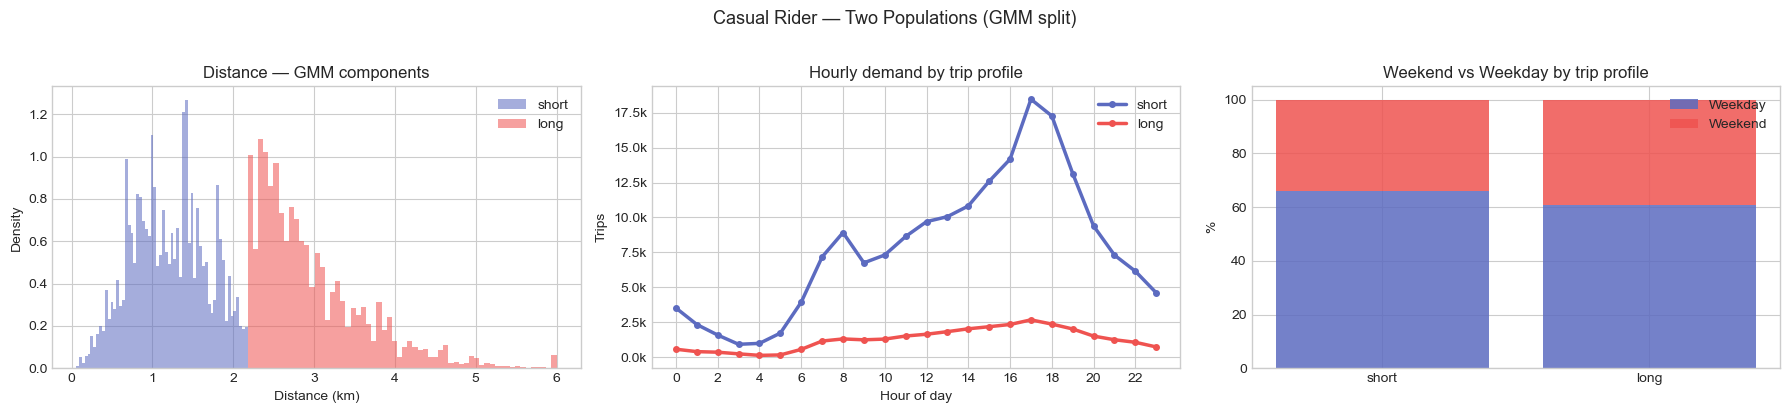

In [7]:
dist_df = df[df['distance_km'].notna() & (df['distance_km'] > 0)]
casual_dist = dist_df[dist_df['member_casual'] == 'casual']['distance_km'].clip(upper=6)
member_dist = dist_df[dist_df['member_casual'] == 'member']['distance_km'].clip(upper=6)

# ── 1. KDE + PEAK DETECTION ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

x = np.linspace(0, 6, 1000)

for ax, series, label, color in [
    (axes[0], casual_dist, 'Casual', COLORS['casual']),
    (axes[1], member_dist, 'Member', COLORS['member']),
]:
    kde = gaussian_kde(series, bw_method=0.15)
    density = kde(x)

    peaks, props = find_peaks(density, prominence=0.02)

    ax.plot(x, density, color=color, linewidth=2.5)
    ax.fill_between(x, density, alpha=0.15, color=color)
    ax.scatter(x[peaks], density[peaks],
               color='black', zorder=5, s=60,
               label=[f'Peak at {x[p]:.2f} km' for p in peaks])

    for p in peaks:
        ax.annotate(f'{x[p]:.2f} km',
                    xy=(x[p], density[p]),
                    xytext=(x[p] + 0.2, density[p] + 0.01),
                    fontsize=9, color='black',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1))

    ax.set_title(f'{label} — KDE with peaks', fontsize=12)
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Density')
    ax.legend(title='Detected peaks')

plt.tight_layout()
savefig('bimodal_01_kde_peaks')  
plt.show()


# ── 2. GAUSSIAN MIXTURE MODEL — fit 1 and 2 components, compare BIC ──
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, series, label, color in [
    (axes[0], casual_dist, 'Casual', COLORS['casual']),
    (axes[1], member_dist, 'Member', COLORS['member']),
]:
    X = series.values.reshape(-1, 1)

    bic_scores = {}
    models = {}
    for n in [1, 2, 3]:
        gm = GaussianMixture(n_components=n, random_state=42, n_init=5)
        gm.fit(X)
        bic_scores[n] = gm.bic(X)
        models[n] = gm

    best_n = min(bic_scores, key=bic_scores.get)
    best_model = models[best_n]

    print(f"\n{label} — BIC scores: {bic_scores}")
    print(f"  Best fit: {best_n} component(s)")
    if best_n > 1:
        for i, (mean, std, weight) in enumerate(zip(
            best_model.means_.flatten(),
            np.sqrt(best_model.covariances_.flatten()),
            best_model.weights_,
        )):
            print(f"  Component {i+1}: mean={mean:.2f} km, "
                  f"std={std:.2f}, weight={weight:.2%}")

    # Plot histogram + GMM components
    ax.hist(series, bins=60, density=True,
            alpha=0.3, color=color, label='Data')

    x_plot = np.linspace(0, 6, 500).reshape(-1, 1)
    for i in range(best_n):
        from scipy.stats import norm
        mean  = best_model.means_[i, 0]
        std   = np.sqrt(best_model.covariances_[i, 0, 0])
        w     = best_model.weights_[i]
        comp  = w * norm.pdf(x_plot.flatten(), mean, std)
        ax.plot(x_plot, comp, linewidth=2,
                linestyle='--', label=f'Component {i+1}: μ={mean:.2f} km')

    total_density = np.exp(best_model.score_samples(x_plot))
    ax.plot(x_plot, total_density,
            color='black', linewidth=2, label='GMM total')

    ax.set_title(f'{label} — GMM ({best_n} component fit)', fontsize=12)
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
savefig('bimodal_02_gmm_components')
plt.show()


# ── 3. IF BIMODAL — SPLIT AND PROFILE THE TWO POPULATIONS ────────────
gm_casual = GaussianMixture(n_components=2, random_state=42, n_init=5)
casual_full = dist_df[dist_df['member_casual'] == 'casual'].copy()
gm_casual.fit(casual_full['distance_km'].values.reshape(-1, 1))

casual_full['gmm_component'] = gm_casual.predict(
    casual_full['distance_km'].values.reshape(-1, 1)
)

# Label by mean — component with lower mean = short trips
means = gm_casual.means_.flatten()
short_label = int(np.argmin(means))
long_label  = int(np.argmax(means))
casual_full['trip_profile'] = casual_full['gmm_component'].map(
    {short_label: 'short', long_label: 'long'}
)

print("\nCasual rider GMM split:")
print(casual_full['trip_profile'].value_counts())

print("\nProfile comparison:")
print(
    casual_full.groupby('trip_profile').agg(
        n             = ('ride_id',       'count'),
        median_dist   = ('distance_km',   'median'),
        median_dur    = ('duration_min',  'median'),
        pct_electric  = ('rideable_type', lambda x: (x == 'electric_bike').mean() * 100),
        pct_weekend   = ('is_weekend',    'mean'),
        pct_rush      = ('is_rush',       'mean'),
    ).round(2)
)

# Visualise the two profiles side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Distance distributions of the two components
for profile, color in [('short', '#5C6BC0'), ('long', '#EF5350')]:
    sub = casual_full[casual_full['trip_profile'] == profile]['distance_km']
    axes[0].hist(sub.clip(upper=6), bins=60, density=True,
                 alpha=0.55, color=color, label=profile)
axes[0].set_title('Distance — GMM components', fontsize=12)
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Hour of day
hourly_profile = (
    casual_full.groupby(['hour', 'trip_profile'])
    .size().reset_index(name='trips')
)
for profile, color in [('short', '#5C6BC0'), ('long', '#EF5350')]:
    sub = hourly_profile[hourly_profile['trip_profile'] == profile]
    axes[1].plot(sub['hour'], sub['trips'],
                 color=color, linewidth=2.5, marker='o', markersize=4,
                 label=profile)
axes[1].set_title('Hourly demand by trip profile', fontsize=12)
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Trips')
axes[1].set_xticks(range(0, 24, 2))
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}k')
)
axes[1].legend()

# Weekend share
wknd_profile = (
    casual_full.groupby(['trip_profile', 'is_weekend'])
    .size().reset_index(name='trips')
)
wknd_profile['pct'] = wknd_profile.groupby('trip_profile')['trips'].transform(
    lambda x: x / x.sum() * 100
)
wknd_profile['day_type'] = wknd_profile['is_weekend'].map(
    {True: 'Weekend', False: 'Weekday'}
)
bottom = np.zeros(2)
profiles = ['short', 'long']
colors_stack = {'Weekday': '#5C6BC0', 'Weekend': '#EF5350'}
for day_type, color in colors_stack.items():
    vals = [
        wknd_profile[
            (wknd_profile['trip_profile'] == p) &
            (wknd_profile['day_type'] == day_type)
        ]['pct'].values[0]
        for p in profiles
    ]
    axes[2].bar(profiles, vals, bottom=bottom,
                color=color, alpha=0.85, label=day_type)
    bottom += np.array(vals)
axes[2].set_title('Weekend vs Weekday by trip profile', fontsize=12)
axes[2].set_ylabel('%')
axes[2].legend()

plt.suptitle('Casual Rider — Two Populations (GMM split)', fontsize=13, y=1.02)
plt.tight_layout()
savefig('bimodal_03_casual_profiles')
plt.show()

The casual distance distribution appears bimodal at first glance, but the GMM analysis tells a more nuanced story. Fitting Gaussian mixture models with 1, 2, and 3 components shows that while 2 components produce a large BIC improvement over 1 (514,749 → 457,302), the jump to 3 components is marginal (→ 452,620), suggesting two sub-populations do most of the explanatory work. However, when those two groups are profiled against behaviour — bike type preference (74% vs 77% electric), weekend share (34% vs 39%), and rush hour share (38% vs 35%) — the differences are negligible. The split is in distance and duration only, not in when or how people ride. The most likely explanation is not two distinct rider types but a single casual population making trips of varying length depending on destination. The distribution is weakly bimodal in a statistical sense, but not behaviourally meaningful — the member/casual split remains the more structurally significant segmentation in this dataset.

  Saved → ../figures\07_speed_analysis.png


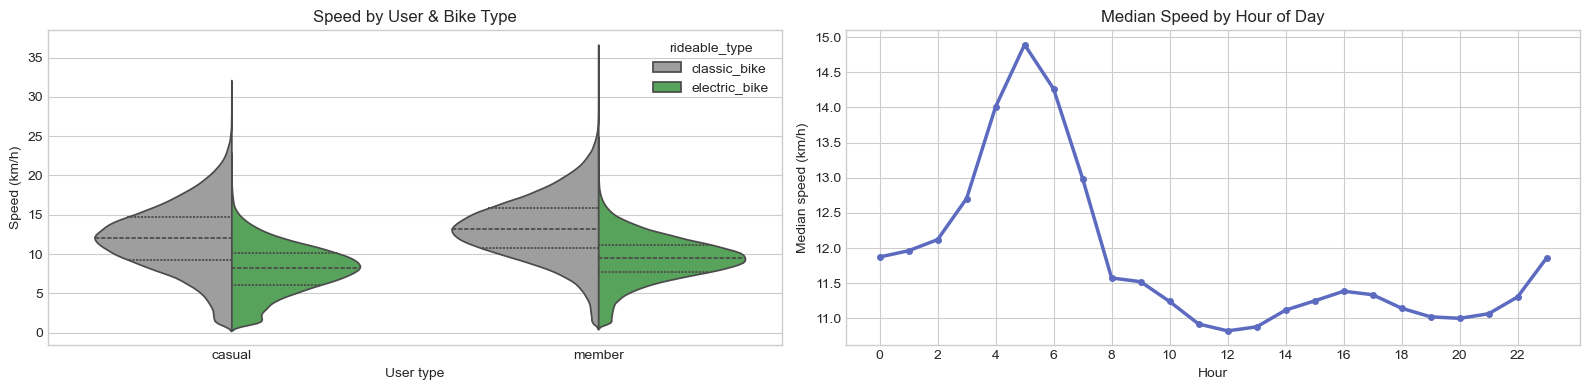

In [14]:
speed_df = df[df['speed_kmh'].notna() & df['speed_kmh'].between(1, 40)]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Violin: speed by user × bike type
sns.violinplot(
    data=speed_df,
    x='member_casual', y='speed_kmh',
    hue='rideable_type',
    palette={'electric_bike': COLORS['electric'], 'classic_bike': COLORS['classic']},
    ax=axes[0], split=True, inner='quart'
)
axes[0].set_title('Speed by User & Bike Type', fontsize=12)
axes[0].set_xlabel('User type')
axes[0].set_ylabel('Speed (km/h)')

# Median speed by hour
hourly_speed = speed_df.groupby('hour')['speed_kmh'].median().reset_index()
axes[1].plot(hourly_speed['hour'], hourly_speed['speed_kmh'],
             linewidth=2.5, color=COLORS['jc'], marker='o', markersize=4)
axes[1].set_title('Median Speed by Hour of Day', fontsize=12)
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Median speed (km/h)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
savefig('07_speed_analysis')
plt.show()

Speed is more a function of time of day and traffic conditions than of user type or bike type. The hourly chart shows a ~4 km/h range across the day driven by who is riding and how busy the roads are. The violin chart shows only a ~2–3 km/h gap between electric and classic, and almost no gap between members and casuals. 

## Section 3 - Member vs casual deep dive

  Saved → ../figures\08_member_casual_behaviour.png


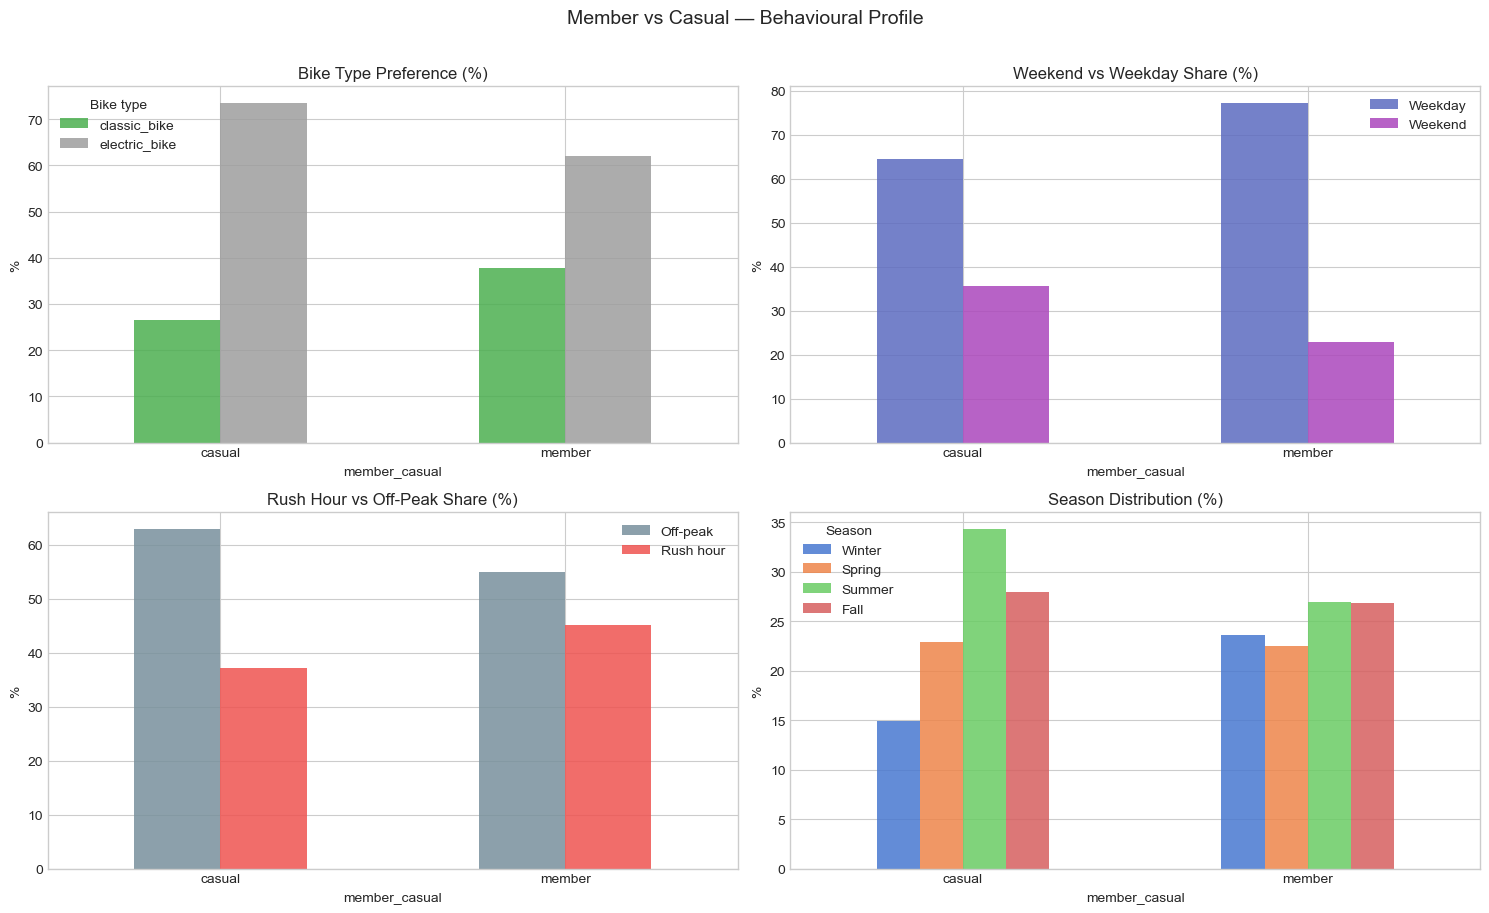

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# 1. Bike type preference
ride_pref = (df.groupby(['member_casual', 'rideable_type'])
               .size().unstack(fill_value=0))
ride_pct = ride_pref.div(ride_pref.sum(axis=1), axis=0) * 100
ride_pct.plot(kind='bar', ax=axes[0,0],
              color=[COLORS['electric'], COLORS['classic']],
              alpha=0.85, width=0.5)
axes[0,0].set_title('Bike Type Preference (%)', fontsize=12)
axes[0,0].set_ylabel('%')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].legend(title='Bike type')

# 2. Weekend share
wknd = (df.groupby(['member_casual', 'is_weekend'])
          .size().unstack(fill_value=0))
wknd_pct = wknd.div(wknd.sum(axis=1), axis=0) * 100
wknd_pct.columns = ['Weekday', 'Weekend']
wknd_pct.plot(kind='bar', ax=axes[0,1],
              color=['#5C6BC0', '#AB47BC'], alpha=0.85, width=0.5)
axes[0,1].set_title('Weekend vs Weekday Share (%)', fontsize=12)
axes[0,1].set_ylabel('%')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend()

# 3. Rush hour share
rush = (df.groupby(['member_casual', 'is_rush'])
          .size().unstack(fill_value=0))
rush_pct = rush.div(rush.sum(axis=1), axis=0) * 100
rush_pct.columns = ['Off-peak', 'Rush hour']
rush_pct.plot(kind='bar', ax=axes[1,0],
              color=['#78909C', '#EF5350'], alpha=0.85, width=0.5)
axes[1,0].set_title('Rush Hour vs Off-Peak Share (%)', fontsize=12)
axes[1,0].set_ylabel('%')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend()

# 4. Season distribution
season_split = (df.groupby(['member_casual', 'season'])
                  .size().unstack(fill_value=0))
season_pct = season_split.div(season_split.sum(axis=1), axis=0) * 100
season_pct[['Winter','Spring','Summer','Fall']].plot(
    kind='bar', ax=axes[1,1], alpha=0.85, width=0.5
)
axes[1,1].set_title('Season Distribution (%)', fontsize=12)
axes[1,1].set_ylabel('%')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='Season')

plt.suptitle('Member vs Casual — Behavioural Profile', fontsize=14, y=1.01)
plt.tight_layout()
savefig('08_member_casual_behaviour')
plt.show()

A member is a habitual, utility-driven rider. They commute on weekdays, ride year-round, are comfortable on classic bikes, and show up reliably regardless of season or weather. The system is infrastructure for them — like a bus or subway.
A casual rider is an opportunistic, comfort-driven rider. They prefer electric bikes, skew slightly toward weekends and summer, avoid rush hours, and are highly sensitive to season. The system is an experience for them — something they choose when conditions are right.

In [16]:
from scipy import stats

member_dur = df.loc[df['member_casual'] == 'member', 'duration_min'].dropna()
casual_dur = df.loc[df['member_casual'] == 'casual', 'duration_min'].dropna()

stat, p = stats.mannwhitneyu(member_dur, casual_dur, alternative='two-sided')

print("Mann-Whitney U — Trip Duration: Member vs Casual")
print(f"  U statistic:  {stat:,.0f}")
print(f"  p-value:      {p:.2e}")
print(f"  Result:       {'Significant (p < 0.05)' if p < 0.05 else 'Not significant'}")
print(f"\n  Median — member:  {member_dur.median():.2f} min")
print(f"  Median — casual:  {casual_dur.median():.2f} min")
print(f"  Casual/member ratio: {casual_dur.median()/member_dur.median():.2f}×")

Mann-Whitney U — Trip Duration: Member vs Casual
  U statistic:  68,442,224,068
  p-value:      0.00e+00
  Result:       Significant (p < 0.05)

  Median — member:  5.53 min
  Median — casual:  7.91 min
  Casual/member ratio: 1.43×


Median trip duration is 5.53 minutes for members and 7.91 minutes for casual riders — a 1.43× difference. A Mann-Whitney U test confirms this difference is statistically significant (U = 68,442,224,068, p ≈ 0.00). The Mann-Whitney test was chosen over a t-test because trip duration is heavily right-skewed — a small number of very long trips would distort a mean-based test. With 1.09 million observations the test has effectively infinite statistical power, meaning even a trivial difference would register as significant; the meaningful result here is therefore not the p-value but the 2.4-minute gap in medians, which is consistent, robust, and large enough to reflect a genuine behavioural difference. Members take short, purposeful trips. Casual riders take longer, more varied ones. 

## Section 4 - Station analysis

  Saved → ../figures\09_top_start_stations.png


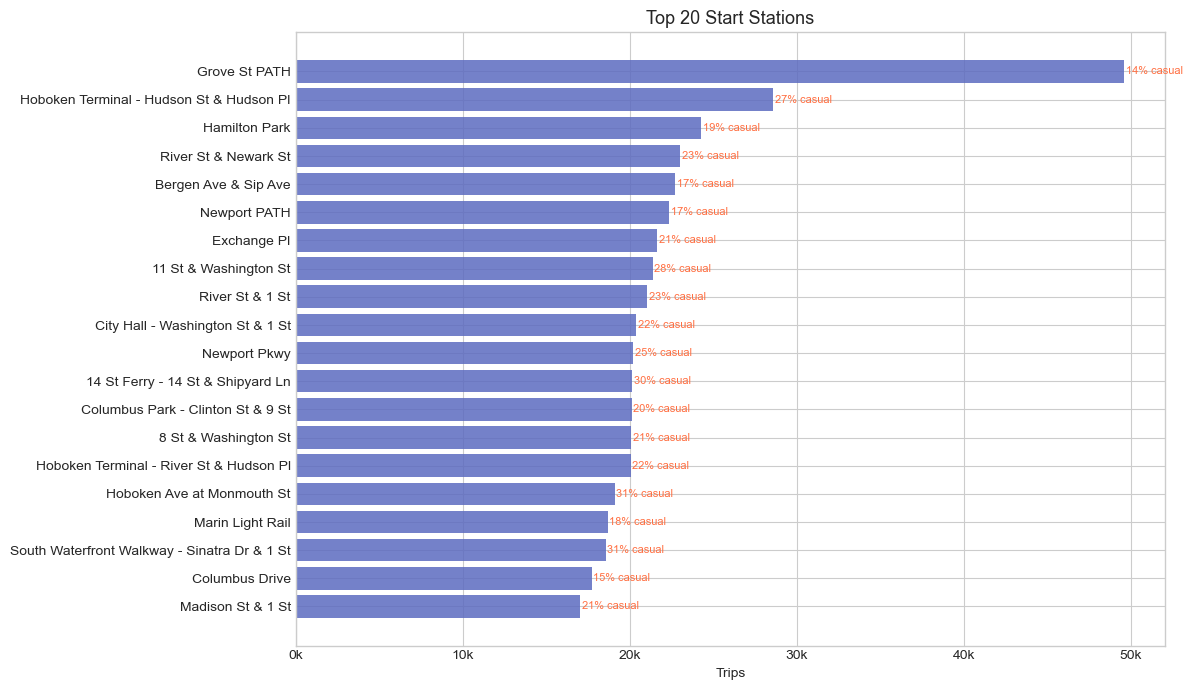

In [17]:
# Use start stations only — the 112 real network stations
top_start = (df['start_station_name']
             .value_counts()
             .head(20)
             .reset_index())
top_start.columns = ['station', 'trips']

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_start['station'], top_start['trips'],
        color=COLORS['jc'], alpha=0.85)
ax.invert_yaxis()
ax.set_title('Top 20 Start Stations', fontsize=13)
ax.set_xlabel('Trips')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Member vs casual split per station
top_names = top_start['station'].tolist()
split = (df[df['start_station_name'].isin(top_names)]
         .groupby(['start_station_name', 'member_casual'])
         .size()
         .unstack(fill_value=0))
split_pct = split.div(split.sum(axis=1), axis=0).reindex(top_names)

# Overlay casual % as text
for i, station in enumerate(top_names):
    if station in split_pct.index:
        pct = split_pct.loc[station, 'casual'] * 100
        ax.text(top_start.loc[top_start['station']==station, 'trips'].values[0] + 100,
                i, f'{pct:.0f}% casual', va='center', fontsize=8, color=COLORS['casual'])

plt.tight_layout()
savefig('09_top_start_stations')
plt.show()

  Saved → ../figures\10_station_net_flow.png


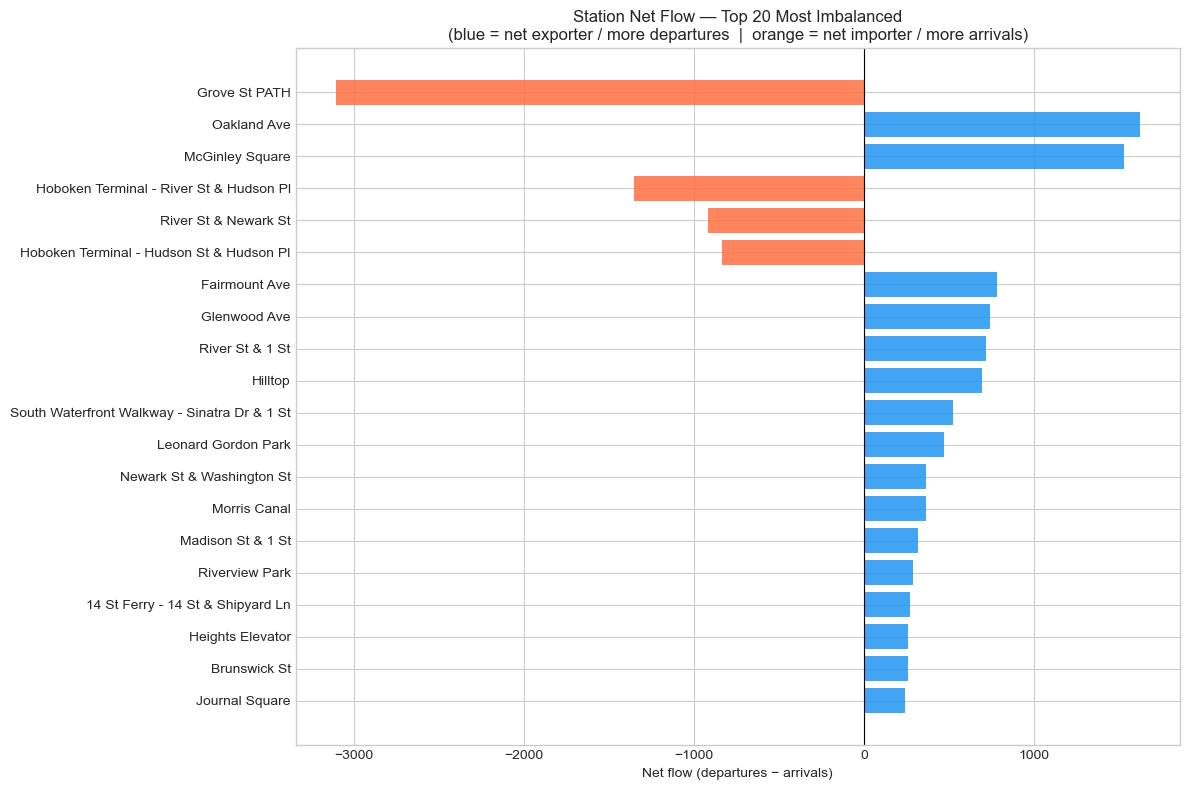


Top 10 net exporters (bikes drain from here):
                                              departures  arrivals  net_flow
Oakland Ave                                         8481      6860      1621
McGinley Square                                    12394     10863      1531
Fairmount Ave                                       5579      4799       780
Glenwood Ave                                        3929      3187       742
River St & 1 St                                    21028     20312       716
Hilltop                                             8720      8027       693
South Waterfront Walkway - Sinatra Dr & 1 St       18558     18033       525
Leonard Gordon Park                                 3997      3527       470
Newark St & Washington St                          11202     10837       365
Morris Canal                                       11742     11381       361

Top 10 net importers (bikes accumulate here):
                                          departures  arriv

In [18]:
departures = df['start_station_name'].value_counts().rename('departures')
arrivals   = df['end_station_name'].isin(
                 df['start_station_name'].unique()  # only count arrivals at real stations
             )
# Use only end stations that are real network stations
valid_ends = df[df['end_station_name'].isin(departures.index)]
arrivals   = valid_ends['end_station_name'].value_counts().rename('arrivals')

flow = pd.concat([departures, arrivals], axis=1).fillna(0)
flow['net_flow']    = flow['departures'] - flow['arrivals']
flow['total_trips'] = flow['departures'] + flow['arrivals']

top_flow = (flow[flow['total_trips'] >= 500]
            .reindex(flow['net_flow'].abs().nlargest(20).index))

fig, ax = plt.subplots(figsize=(12, 8))
bar_colors = [COLORS['member'] if v > 0 else COLORS['casual']
              for v in top_flow['net_flow']]
ax.barh(top_flow.index, top_flow['net_flow'], color=bar_colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Station Net Flow — Top 20 Most Imbalanced\n'
             '(blue = net exporter / more departures  |  orange = net importer / more arrivals)',
             fontsize=12)
ax.set_xlabel('Net flow (departures − arrivals)')
ax.invert_yaxis()

plt.tight_layout()
savefig('10_station_net_flow')
plt.show()

print("\nTop 10 net exporters (bikes drain from here):")
print(flow.nlargest(10, 'net_flow')[['departures','arrivals','net_flow']].to_string())
print("\nTop 10 net importers (bikes accumulate here):")
print(flow.nsmallest(10, 'net_flow')[['departures','arrivals','net_flow']].to_string())

The net flow data reveals a clear and chronic rebalancing problem across the network. **Grove St PATH station alone accumulates 3,108 more bikes than it dispatches** — the single most imbalanced station in the network — followed by both Hoboken Terminal entrances (−1,352 and −835). These are all major transit hubs, which tells a consistent story: riders cycle *to* PATH and ferry connections in the morning and don't bring bikes back, draining residential neighbourhood stations like Oakland Ave (+1,621) and McGinley Square (+1,531) of their supply. The result is a predictable daily cycle where commuter-origin stations run out of bikes during AM peak and transit-hub stations overflow — a structural imbalance that passive redistribution cannot solve and that grows worse on high-ridership days. This data provides the empirical foundation for a targeted rebalancing intervention: the problem stations are known, the direction of flow is known, and with the hourly trip data already available, the *timing* of when each station tips into deficit can be modelled precisely.

## Section 5 - Rideable type analysis

  Saved → ../figures\11_rideable_type_analysis.png


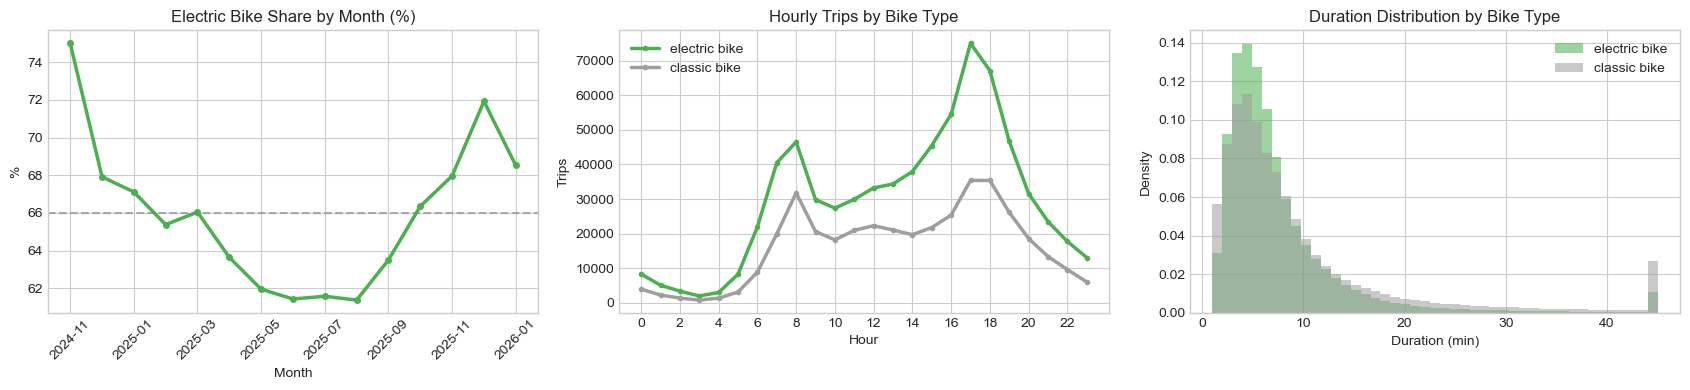

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Monthly share
monthly_bike = (df.groupby(['month', 'rideable_type'])
                  .size()
                  .unstack(fill_value=0))
monthly_bike_pct = monthly_bike.div(monthly_bike.sum(axis=1), axis=0) * 100
monthly_bike_pct['electric_bike'].plot(
    ax=axes[0], color=COLORS['electric'], linewidth=2.5, marker='o', markersize=4
)
axes[0].set_title('Electric Bike Share by Month (%)', fontsize=12)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(monthly_bike_pct['electric_bike'].mean(), linestyle='--',
                color='gray', alpha=0.6)

# Hourly usage by bike type
hourly_bike = (df.groupby(['hour', 'rideable_type'])
                 .size()
                 .unstack(fill_value=0))
for bike, color in [('electric_bike', COLORS['electric']),
                    ('classic_bike',  COLORS['classic'])]:
    axes[1].plot(hourly_bike.index, hourly_bike[bike],
                 color=color, linewidth=2.5, marker='o', markersize=3,
                 label=bike.replace('_', ' '))
axes[1].set_title('Hourly Trips by Bike Type', fontsize=12)
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Trips')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

# Duration by bike type
for bike, color in [('electric_bike', COLORS['electric']),
                    ('classic_bike',  COLORS['classic'])]:
    sub = df.loc[df['rideable_type'] == bike, 'duration_min'].clip(upper=45)
    axes[2].hist(sub, bins=45, alpha=0.55, color=color,
                 label=bike.replace('_', ' '), density=True)
axes[2].set_title('Duration Distribution by Bike Type', fontsize=12)
axes[2].set_xlabel('Duration (min)')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
savefig('11_rideable_type_analysis')
plt.show()

  Saved → ../figures\12_network_analysis.png


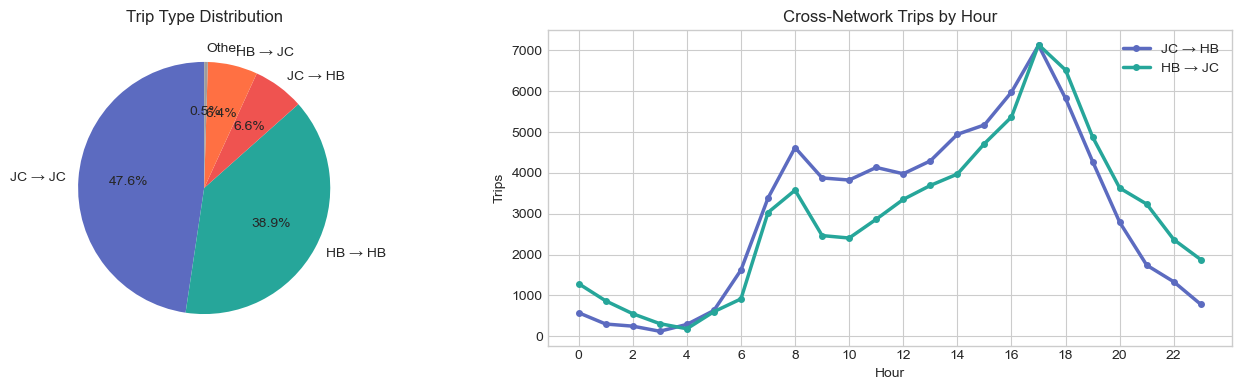


Trip type breakdown:
trip_type
JC → JC    521068
HB → HB    425818
JC → HB     71884
HB → JC     69818
Other        5097

Cross-network trips by user type:
member_casual  casual  member
trip_type                    
HB → JC         19808   50010
JC → HB         20180   51704


In [22]:
# Trip type classification
def trip_type(row):
    s = str(row['start_network'])
    e = str(row['end_network'])
    if s == 'jersey_city'  and e == 'jersey_city':  return 'JC → JC'
    if s == 'hoboken'      and e == 'hoboken':       return 'HB → HB'
    if s == 'jersey_city'  and e == 'hoboken':       return 'JC → HB'
    if s == 'hoboken'      and e == 'jersey_city':   return 'HB → JC'
    return 'Other'

df['trip_type'] = df.apply(trip_type, axis=1).astype('category')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall split
tt_counts = df['trip_type'].value_counts()
axes[0].pie(tt_counts, labels=tt_counts.index, autopct='%1.1f%%',
            colors=['#5C6BC0','#26A69A','#EF5350','#FF7043','#9E9E9E'],
            startangle=90)
axes[0].set_title('Trip Type Distribution', fontsize=12)

# Cross-network trips by hour
cross = df[df['trip_type'].isin(['JC → HB', 'HB → JC'])]
cross_hourly = (cross.groupby(['hour', 'trip_type'])
                     .size()
                     .unstack(fill_value=0))
for col, color in zip(['JC → HB', 'HB → JC'],
                      [COLORS['jc'], COLORS['hoboken']]):
    if col in cross_hourly.columns:
        axes[1].plot(cross_hourly.index, cross_hourly[col],
                     linewidth=2.5, marker='o', markersize=4,
                     color=color, label=col)
axes[1].set_title('Cross-Network Trips by Hour', fontsize=12)
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Trips')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.tight_layout()
savefig('12_network_analysis')
plt.show()

print("\nTrip type breakdown:")
print(df['trip_type'].value_counts().to_string())

print("\nCross-network trips by user type:")
print(cross.groupby(['trip_type', 'member_casual']).size().unstack().to_string())

In [24]:
summary = df.groupby('member_casual').agg(
    trips          = ('ride_id',      'count'),
    median_dur_min = ('duration_min', 'median'),
    median_dist_km = ('distance_km',  'median'),
    pct_electric   = ('rideable_type', lambda x: (x == 'electric_bike').mean() * 100),
    pct_weekend    = ('is_weekend',    'mean'),
    pct_rush       = ('is_rush',       'mean'),
).round(2)

summary['pct_weekend'] = (summary['pct_weekend'] * 100).round(1)
summary['pct_rush']    = (summary['pct_rush']    * 100).round(1)

print("\nBehavioural summary by user type:")
print(summary.T.to_string())


Behavioural summary by user type:
member_casual      casual     member
trips           235837.00  857848.00
median_dur_min       7.91       5.53
median_dist_km       1.26       1.00
pct_electric        73.45      62.13
pct_weekend         36.00      23.00
pct_rush            37.00      45.00


### Weather data

In [2]:
import pandas as pd
import requests
from io import StringIO

# NOAA LCD data for LaGuardia (station USW00014732)
# Daily summaries Dec 2024 – Jan 2026
url = (
    "https://www.ncei.noaa.gov/access/services/data/v1"
    "?dataset=daily-summaries"
    "&stations=USW00014732"
    "&startDate=2024-12-01"
    "&endDate=2026-01-31"
    "&dataTypes=TMAX,TMIN,TAVG,PRCP,SNOW,AWND"
    "&format=csv"
    "&units=metric"
)

response = requests.get(url)
weather_raw = pd.read_csv(StringIO(response.text))
print(weather_raw.head())
print(weather_raw.shape)
print(weather_raw.columns.tolist())

       STATION        DATE  AWND  PRCP  SNOW  TAVG  TMAX  TMIN
0  USW00014732  2024-12-01   6.0   0.0   0.0   0.7   3.9  -1.6
1  USW00014732  2024-12-02   5.6   0.0   0.0   1.8   5.0  -0.5
2  USW00014732  2024-12-03   5.5   0.0   0.0   2.5   6.1   1.1
3  USW00014732  2024-12-04   5.4   0.5   0.0   2.3   5.6   0.6
4  USW00014732  2024-12-05   8.4   2.8   0.0   3.8  10.0   0.6
(427, 8)
['STATION', 'DATE', 'AWND', 'PRCP', 'SNOW', 'TAVG', 'TMAX', 'TMIN']


In [3]:
# ── Clean & engineer weather features ─────────────────────────────
weather = weather_raw.copy()
weather['DATE'] = pd.to_datetime(weather['DATE'])
weather = weather.rename(columns={
    'DATE': 'date',
    'TAVG': 'temp_avg',
    'TMAX': 'temp_max',
    'TMIN': 'temp_min',
    'PRCP': 'precipitation',
    'SNOW': 'snow',
    'AWND': 'wind_speed'
}).drop(columns='STATION')

# Fill missing TAVG with (TMAX + TMIN) / 2
weather['temp_avg'] = weather['temp_avg'].fillna(
    (weather['temp_max'] + weather['temp_min']) / 2
)

# Engineered features
weather['is_rain']       = weather['precipitation'] > 1.0   # >1mm = meaningful rain
weather['is_snow']       = weather['snow'] > 0
weather['temp_category'] = pd.cut(
    weather['temp_avg'],
    bins=[-30, 0, 10, 20, 40],
    labels=['Freezing', 'Cold', 'Mild', 'Warm']
)

print(weather.shape)
print(weather.dtypes)
print(f"\nRainy days:  {weather['is_rain'].sum()}")
print(f"Snowy days:  {weather['is_snow'].sum()}")
print(weather[['temp_avg','precipitation','wind_speed']].describe().round(2))

(427, 10)
date             datetime64[ns]
wind_speed              float64
precipitation           float64
snow                    float64
temp_avg                float64
temp_max                float64
temp_min                float64
is_rain                    bool
is_snow                    bool
temp_category          category
dtype: object

Rainy days:  110
Snowy days:  20
       temp_avg  precipitation  wind_speed
count    427.00         427.00      422.00
mean      11.71           2.56        5.00
std       10.02           6.59        1.84
min       -9.40           0.00        1.40
25%        3.45           0.00        3.62
50%       11.40           0.00        4.60
75%       20.60           1.30        6.00
max       31.90          53.10       11.20


In [9]:
# ── Build daily trip counts ────────────────────────────────────────
df['date'] = df['started_at'].dt.date
df['date'] = pd.to_datetime(df['date'])

# ── Fix FutureWarning ─────────────────────────────────────────────
daily = (df.groupby(['date', 'member_casual'], observed=True)
           .agg(trips=('ride_id', 'count'),
                median_duration=('duration_min', 'median'))
           .reset_index())

daily_wide = (df.groupby('date', observed=True)
                .agg(
                    trips_total  = ('ride_id',       'count'),
                    trips_member = ('member_casual', lambda x: (x=='member').sum()),
                    trips_casual = ('member_casual', lambda x: (x=='casual').sum()),
                    median_dur   = ('duration_min',  'median'),
                )
                .reset_index())
daily_wide['casual_pct'] = daily_wide['trips_casual'] / daily_wide['trips_total'] * 100

# ── Merge ─────────────────────────────────────────────────────────
daily_weather = daily_wide.merge(weather, on='date', how='left')

missing_weather = daily_weather['temp_avg'].isna().sum()
print(f"Days missing weather data: {missing_weather}")
print(f"Merged shape: {daily_weather.shape}")

# ── Key relationships preview ──────────────────────────────────────
print("\nAvg daily trips by rain:")
print(daily_weather.groupby('is_rain', observed=True)['trips_total']
                   .agg(['mean','median']).round(0))

print("\nAvg daily trips by temperature category:")
print(daily_weather.groupby('temp_category', observed=True)['trips_total']
                   .agg(['mean','median']).round(0))

# ── Save ──────────────────────────────────────────────────────────
daily_weather.to_csv('../data/daily_weather_merged.csv', index=False)
print("\nSaved → ../data/daily_weather_merged.csv")

Days missing weather data: 1
Merged shape: (428, 15)

Avg daily trips by rain:
           mean  median
is_rain                
False    2711.0  2833.0
True     2131.0  2082.0

Avg daily trips by temperature category:
                 mean  median
temp_category                
Freezing       1223.0  1214.0
Cold           1957.0  2032.0
Mild           2956.0  3068.0
Warm           3598.0  3645.0

Saved → ../data/daily_weather_merged.csv
